# 16 — Qué información utiliza el modelo semanal con memoria larga

Se reconstruye exactamente el ajuste de agosto de 2026 del candidato de 15 y se verifica que reproduzca sus predicciones. Entrena sólo con semanas cerradas al primer origen de agosto. La explicación se evalúa en los casos principales de agosto, no en entrenamiento. Es una fotografía del modelo de ese mes y del candidato seleccionado retrospectivamente; no explica todo 2026 ni establece causalidad.

Se usa **importancia por permutación**, no SHAP: cuánto aumenta el WAPE al desordenar una variable o un bloque en los casos de evaluación. Se perturban variables del dato original, antes de imputar/codificar. Las columnas de cada bloque se permutan juntas. Se incluyen la referencia sumada (media4 o teoría), el corrector y el recorte en cero. Por eso se explica la predicción final, no sólo el residuo.

Cinco repeticiones por variable/bloque, semilla fija, sin reajustar el modelo. El intervalo mostrado es la desviación entre permutaciones, no un intervalo de confianza. Variables correlacionadas pueden sustituirse entre sí; por eso se presentan bloques además de columnas. Permutar puede producir combinaciones poco habituales: las importancias no son una recomendación automática para eliminar datos.

Entradas y funciones están aquí; no se ejecutan otros notebooks ni se leen modelos serializados.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


In [3]:
llave=KEY+['origen','semana_objetivo','horizonte']
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


## 1. Reproducir el modelo y separar las dos rutas

Hay dos grupos de horizonte (H1–H2 y H3–H5). En cada uno, el respaldo aprende el ajuste sobre media4 usando todos sus casos de entrenamiento; la ruta teórica aprende el ajuste sobre teoría con los casos completos. La importancia de cada ruta se calcula sólo en los casos donde efectivamente se usa.

Los casos con poco soporte se muestran con su tamaño: no se extrapolan sus rankings a toda la finca. Mantener producto/color/variedad juntos en el bloque de identidad evita romper esa identidad al evaluar bloques.

In [4]:
guardadas=pd.read_parquet(DESTINO/'experimentos_horizontes_2026.parquet')
mes_explicado='2026-08'
te=elegibles.loc[elegibles.origen.dt.to_period('M').astype(str).eq(mes_explicado)].copy()
corte=te.origen.min()
tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
assert tr.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
FIG=ROOT/'Trabajo escrito/Figuras_resultados'; FIG.mkdir(exist_ok=True)
bloques={'Identidad comercial':categoricas,'Horizonte y calendario':temporales,'Producción semanal reciente':memoria,'Memoria larga':extra_cols,'Clima semanal':climaticas,'Corte diario reciente':[c for c in diarias if c.startswith('corte_') or c=='dias_desde_corte'],'Clima diario reciente':[c for c in diarias if c not in ['dias_desde_corte'] and not c.startswith('corte_')],'Teoría y desvío':['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']}
filas=[]; controles=[]; predicciones=[]
for grupo,tt in te.groupby('grupo_h'):
    train=tr.loc[tr.grupo_h.eq(grupo)]
    for ruta,es_teoria in [('Respaldo',False),('Teoria_completa',True)]:
        cols=(Xteoria if es_teoria else Xbase)+extra_cols
        entrenamiento=train.loc[train.curva_completa] if es_teoria else train
        t=tt.loc[tt.curva_completa.eq(es_teoria)].copy()
        assert len(entrenamiento)>=40
        referencia='teoria_modelo' if es_teoria else 'media_4'
        modelo=crear_modelo('Boosting',cols)
        def pronosticar(x):return np.maximum(0,x[referencia].to_numpy()+modelo.predict(x[cols]))
        with threadpool_limits(limits=2):
            modelo.fit(entrenamiento[cols],entrenamiento.y-entrenamiento[referencia])
            t['reproducida']=pronosticar(t)
            comprobacion=t.merge(guardadas[llave+['Memoria_larga']],on=llave,validate='one_to_one')
            assert np.allclose(comprobacion.reproducida,comprobacion.Memoria_larga,rtol=1e-9,atol=1e-6)
            predicciones.append(t[llave+['reproducida']].assign(ruta=ruta,grupo=grupo))
            t=t.merge(guardadas[llave+['grupo_comparacion']],on=llave,validate='one_to_one')
            t=t.loc[t.grupo_comparacion.eq('principal_estricta_nominal')].copy()
            if t.empty:continue
            base_error=np.abs(t.y.to_numpy()-t.reproducida.to_numpy()).sum()/t.y.sum()
            controles.append({'grupo':grupo,'ruta':ruta,'corte':corte,'max_objetivo_train':entrenamiento.semana_objetivo.max(),'n_train':len(entrenamiento),'n_evaluacion':len(t),'WAPE_base':base_error})
            for tipo,unidades in [('Bloque',{k:[c for c in v if c in cols] for k,v in bloques.items()}),('Variable',{c:[c] for c in cols})]:
                for nombre,cc in unidades.items():
                    if not cc:continue
                    rng=np.random.default_rng(42)
                    valores=[]
                    for repeticion in range(5):
                        x=t.copy(); ix=rng.permutation(len(t))
                        x.loc[:,cc]=t.iloc[ix][cc].to_numpy()
                        error=np.abs(t.y.to_numpy()-pronosticar(x)).sum()/t.y.sum()
                        valores.append(100*(error-base_error))
                    filas.append({'grupo':grupo,'ruta':ruta,'tipo':tipo,'variable':nombre,'columnas':'; '.join(cc),'n':len(t),'aumento_WAPE_pp':np.mean(valores),'desviacion_pp':np.std(valores,ddof=1),'min_pp':min(valores),'max_pp':max(valores)})
        print(grupo,ruta,'completado',flush=True)
importancias=pd.DataFrame(filas); controles=pd.DataFrame(controles)
display(controles)
print('Predicciones de agosto reproducidas exactamente antes de permutar.')
display(importancias.loc[importancias.tipo.eq('Bloque')].sort_values(['grupo','ruta','aumento_WAPE_pp'],ascending=[True,True,False]))

H1_H2 Respaldo completado


H1_H2 Teoria_completa completado


H3_H5 Respaldo completado


H3_H5 Teoria_completa completado


,grupo,ruta,corte,max_objetivo_train,n_train,n_evaluacion,WAPE_base
0,H1_H2,Respaldo,2026-08-03,2026-07-27,57382,857,0.139704
1,H1_H2,Teoria_completa,2026-08-03,2026-07-27,16546,79,0.170837
2,H3_H5,Respaldo,2026-08-03,2026-07-27,83612,577,0.167258
3,H3_H5,Teoria_completa,2026-08-03,2026-07-27,24917,47,0.304684


Predicciones de agosto reproducidas exactamente antes de permutar.


,grupo,ruta,tipo,variable,columnas,n,aumento_WAPE_pp,desviacion_pp,min_pp,max_pp
2,H1_H2,Respaldo,Bloque,Producción semanal reciente,produccion_lag1; produccion_lag2; produccion_l...,857,84.046474,0.459433,83.430258,84.502050
5,H1_H2,Respaldo,Bloque,Corte diario reciente,corte_media_3d; corte_suma_3d; corte_dias_3d; ...,857,5.433608,0.231062,5.198000,5.725554
1,H1_H2,Respaldo,Bloque,Horizonte y calendario,horizonte; semana_seno; semana_coseno,857,0.195001,0.142070,-0.022014,0.356786
3,H1_H2,Respaldo,Bloque,Memoria larga,media_12; desv_8; desv_12; reportes_4; reporte...,857,0.053655,0.054722,0.000115,0.145397
0,H1_H2,Respaldo,Bloque,Identidad comercial,producto; color; variedad,857,0.034175,0.035287,-0.015981,0.079295
4,H1_H2,Respaldo,Bloque,Clima semanal,temperatura_semana_lag1; temperatura_semana_me...,857,0.000000,0.000000,0.000000,0.000000
6,H1_H2,Respaldo,Bloque,Clima diario reciente,temperatura_media_3d; temperatura_media_5d; te...,857,0.000000,0.000000,0.000000,0.000000
70,H1_H2,Teoria_completa,Bloque,Teoría y desvío,teoria_modelo; antiguedad_curva; desviacion_re...,79,68.894215,4.207469,64.340357,73.641292
68,H1_H2,Teoria_completa,Bloque,Corte diario reciente,corte_media_3d; corte_suma_3d; corte_dias_3d; ...,79,13.441628,1.907965,11.117147,15.586493
66,H1_H2,Teoria_completa,Bloque,Memoria larga,media_12; desv_8; desv_12; reportes_4; reporte...,79,0.152845,0.148288,-0.042795,0.347227


## 2. Gráficos: bloques y variables, sin confundir importancia con causalidad

Una barra positiva indica que al alterar la información sube el error; una barra cerca de cero indica poca dependencia adicional en estos casos, no ausencia de relación agronómica. Una barra negativa indica que la perturbación mejoró el resultado en esta muestra. Las barras no suman 100 % y no representan tallos aportados. No comparar mecánicamente rutas con denominadores y tamaños distintos.

La teoría entra además como referencia explícita: aun si el corrector la usa poco, la predicción final puede depender mucho de ella. Las revisiones históricas no aparecen porque el candidato Memoria_larga no incluye ese bloque; se evaluaron separadamente en 15.

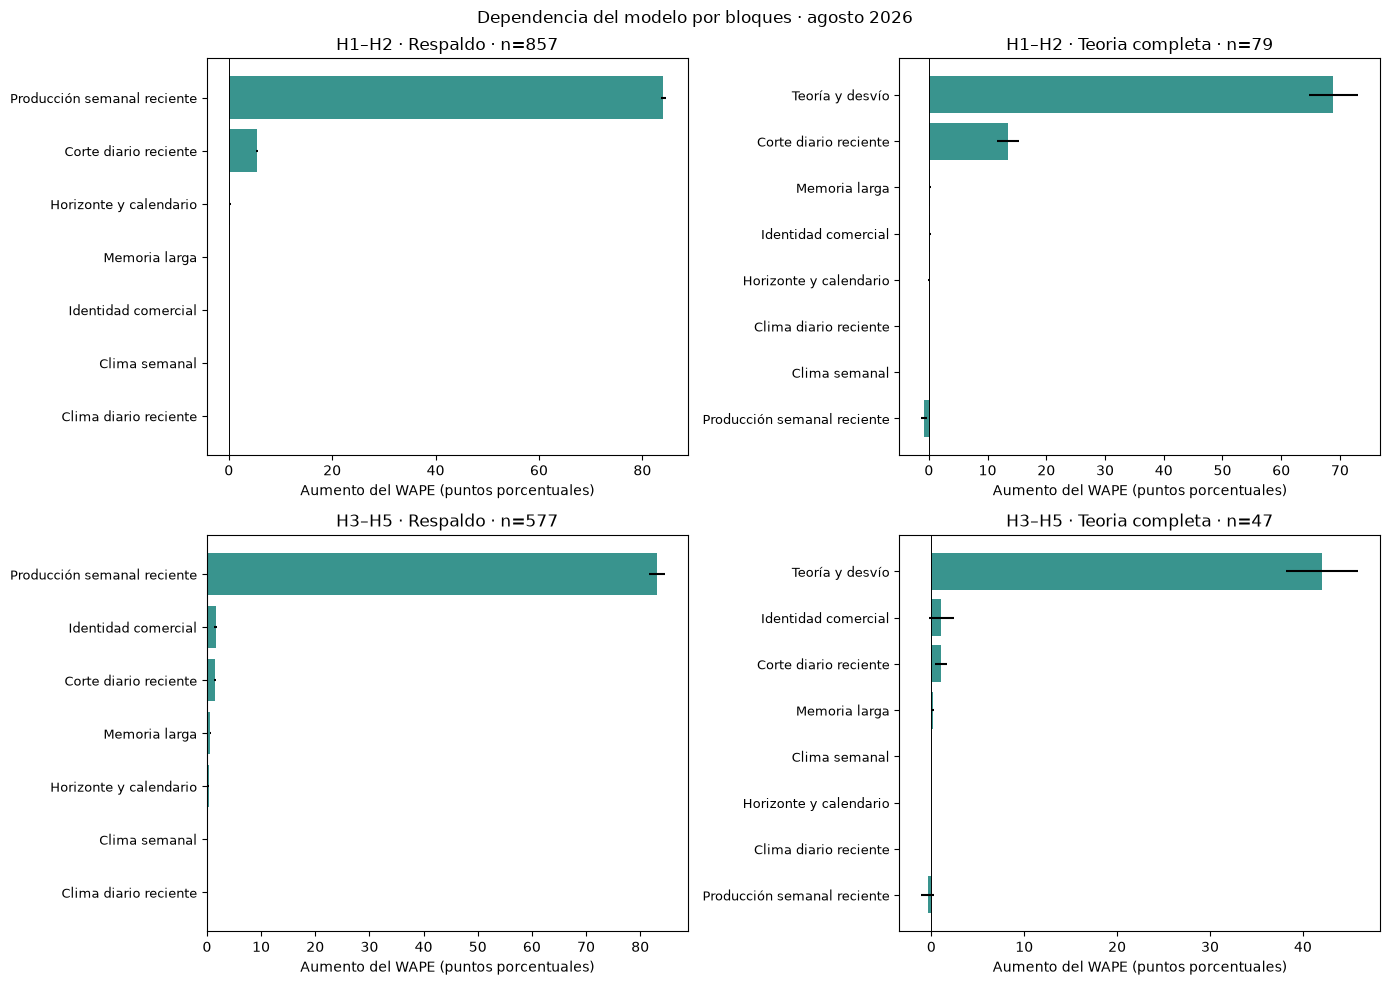

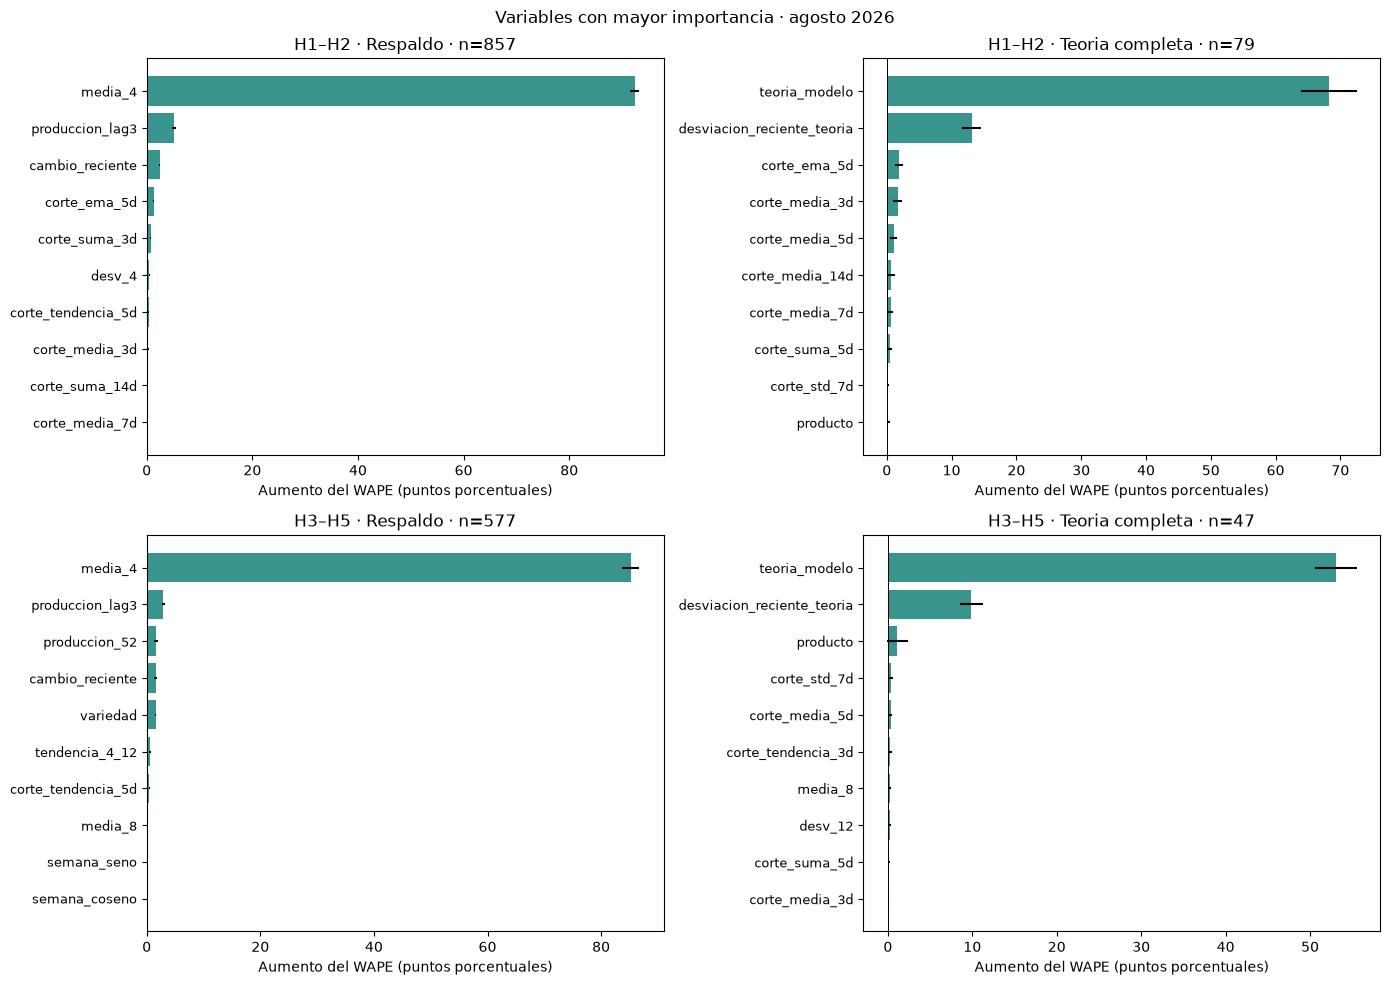

Lectura: dependencia predictiva local al mes evaluado, no explicación causal, no SHAP y no eliminación automática de variables.


In [5]:
for tipo,archivo,titulo in [('Bloque','importancia_bloques_semanal.png','Dependencia del modelo por bloques · agosto 2026'),('Variable','importancia_variables_semanal.png','Variables con mayor importancia · agosto 2026')]:
    fig,axs=plt.subplots(2,2,figsize=(14,10))
    for ax,(grupo,ruta) in zip(axs.flat,[(g,r) for g in ['H1_H2','H3_H5'] for r in ['Respaldo','Teoria_completa']]):
        z=importancias.loc[importancias.tipo.eq(tipo)&importancias.grupo.eq(grupo)&importancias.ruta.eq(ruta)].nlargest(10 if tipo=='Variable' else 20,'aumento_WAPE_pp').sort_values('aumento_WAPE_pp')
        ax.barh(z.variable,z.aumento_WAPE_pp,xerr=z.desviacion_pp,color='#16817a',alpha=.85)
        ax.axvline(0,color='black',lw=.7);ax.set_title(f'{grupo.replace("_","–")} · {ruta.replace("_"," ")} · n={int(z.n.iloc[0])}')
        ax.set_xlabel('Aumento del WAPE (puntos porcentuales)');ax.tick_params(axis='y',labelsize=9)
    fig.suptitle(titulo);fig.tight_layout();fig.savefig(FIG/archivo,dpi=170);plt.show()
importancias.to_parquet(DESTINO/'importancias_memoria_larga.parquet',index=False)
with pd.ExcelWriter(DESTINO/'interpretacion_modelo_semanal.xlsx') as writer:
    controles.to_excel(writer,sheet_name='Cortes_y_casos',index=False)
    importancias.loc[importancias.tipo.eq('Bloque')].to_excel(writer,sheet_name='Bloques',index=False)
    importancias.loc[importancias.tipo.eq('Variable')].to_excel(writer,sheet_name='Variables',index=False)
    pd.concat(predicciones,ignore_index=True).to_excel(writer,sheet_name='Reproduccion_agosto',index=False)
print('Lectura: dependencia predictiva local al mes evaluado, no explicación causal, no SHAP y no eliminación automática de variables.')

## Lectura de esta ejecución

Agosto conserva 1.560 casos principales: respaldo H1–H2/H3–H5 tiene 857/577; teoría completa 79/47. El bloque de producción semanal domina en respaldo y el de teoría/desvío domina con curva completa. El corte diario reciente aporta especialmente en H1–H2. La media4 y la teoría forman parte de la referencia sumada al corrector: romperlas cambia la escala final, por eso sus aumentos de error son grandes.

La importancia marginal pequeña de memoria larga en algunos segmentos no contradice su mejora acumulada en 15: allí se reentrena y se evalúan ocho meses; aquí se perturba un modelo fijo de agosto. No sumar barras, no leerlas como porcentajes de producción ni eliminar automáticamente variables de importancia baja. Consultar 17 para train/test del mismo ajuste y comparaciones completas.